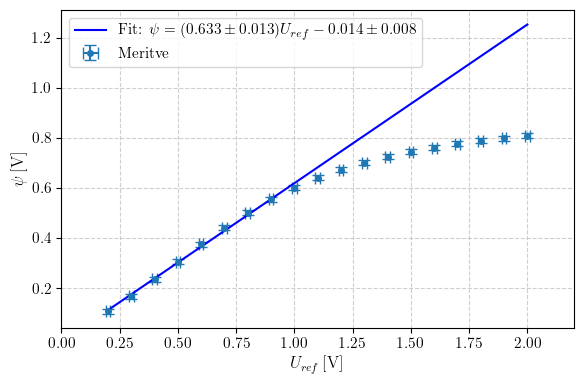

Fit results:
  a (slope)     = 0.63300 ± 0.01291
  b (intercept) = -0.01380 ± 0.00843
  R² = 0.27591
Plot saved as 'psi_vs_Uref_curvefit.pdf'


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------------------------
# Configure LaTeX-style fonts
# ---------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# ---------------------------
# Data
# ---------------------------
U_ref = np.array([
    0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
    1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7,
    1.8, 1.9, 2.0
])

psi = np.array([
    0.109, 0.169, 0.236, 0.305, 0.375, 0.441, 0.502, 0.555,
    0.602, 0.641, 0.673, 0.700, 0.724, 0.745, 0.761, 0.776,
    0.788, 0.799, 0.809
])

error = 0.01  # constant measurement uncertainty

# ---------------------------
# Define linear model for fitting
# ---------------------------
def linear_model(x, a, b):
    return a * x + b

# Perform curve fit with weighting by measurement uncertainty
popt, pcov = curve_fit(linear_model, U_ref[:9], psi[:9], sigma=np.full_like(psi[:9], error), absolute_sigma=True)
a, b = popt                      # Fit parameters
a_err, b_err = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties

# Compute fitted line
fit_line = linear_model(U_ref, a, b)

# Compute R^2 value
residuals = psi - fit_line
ss_res = np.sum(residuals**2)
ss_tot = np.sum((psi - np.mean(psi))**2)
r_squared = 1 - (ss_res / ss_tot)

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(6, 4))
plt.errorbar(U_ref, psi, xerr=error, yerr=error, fmt='o', ms=4, capsize=4,
             label=r'Meritve')
plt.plot(U_ref, fit_line, '-', color='blue',
         label=rf'Fit: $\psi = ({a:.3f} \pm {a_err:.3f})U_{{ref}} {b:.3f} \pm {b_err:.3f}$')

plt.xlabel(r'$U_{ref}\, [\mathrm{V}]$')
plt.ylabel(r'$\psi\, [\mathrm{V}]$')
plt.xlim(0,2.2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()

# ---------------------------
# Save figure for LaTeX
# ---------------------------
plt.savefig("psi_vs_Uref_curvefit.pdf", format='pdf', dpi=300)
plt.show()
plt.close()

print(f"Fit results:")
print(f"  a (slope)     = {a:.5f} ± {a_err:.5f}")
print(f"  b (intercept) = {b:.5f} ± {b_err:.5f}")
print(f"  R² = {r_squared:.5f}")
print("Plot saved as 'psi_vs_Uref_curvefit.pdf'")


part 2

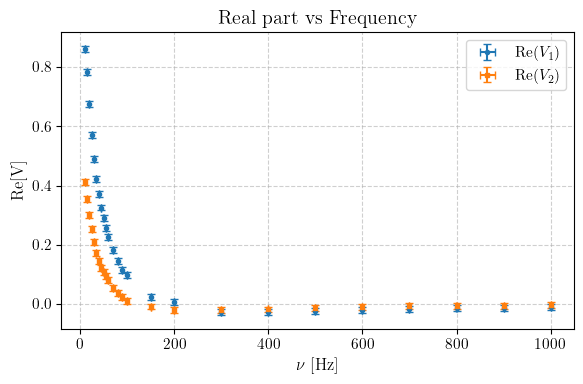

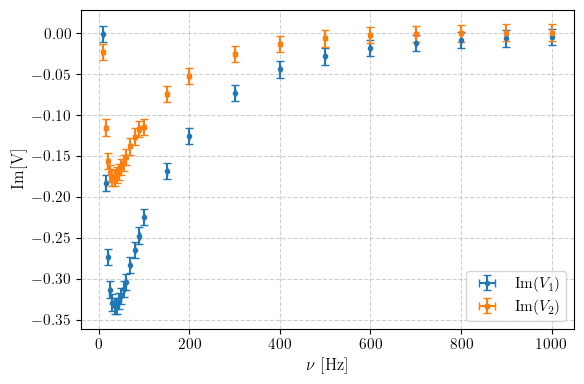

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Configure LaTeX-style fonts
# ---------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# ---------------------------
# Data from the table
# ---------------------------
nu = np.array([
    10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 80, 90, 100,
    150, 200, 300, 400, 500, 600, 700, 800, 900, 1000
])

Re1 = np.array([
    0.862, 0.784, 0.674, 0.571, 0.49, 0.423, 0.37, 0.326, 0.29, 0.257, 0.228,
    0.182, 0.145, 0.115, 0.097, 0.023, 0.007, -0.025, -0.027, -0.024,
    -0.02, -0.017, -0.014, -0.012, -0.01
])

Im1 = np.array([
    0.001, 0.183, 0.273, 0.313, 0.329, 0.333, 0.333, 0.327, 0.321, 0.312, 0.304,
    0.283, 0.265, 0.247, 0.224, 0.168, 0.125, 0.073, 0.044, 0.028,
    0.018, 0.012, 0.008, 0.006, 0.004
])

Re2 = np.array([
    0.411, 0.356, 0.301, 0.254, 0.209, 0.172, 0.145, 0.121, 0.11, 0.095, 0.082,
    0.054, 0.038, 0.025, 0.012, -0.008, -0.02, -0.021, -0.018, -0.014,
    -0.01, -0.007, -0.006, -0.005, -0.003
])

Im2 = np.array([
    0.023, 0.115, 0.156, 0.171, 0.176, 0.177, 0.173, 0.169, 0.163, 0.158, 0.151,
    0.138, 0.126, 0.117, 0.114, 0.074, 0.052, 0.025, 0.013, 0.006,
    0.002, 0.001, 0.0, -0.001, -0.001
])

# ---------------------------
# Errors
# ---------------------------
nu_err = 0.1
V_err = 0.01

# ---------------------------
# Plot 1: Real part with error bars
# ---------------------------
plt.figure(figsize=(6, 4))
plt.errorbar(nu, Re1, xerr=nu_err, yerr=V_err, fmt='o', capsize=3, markersize=3, label=r'Re$(V_1)$')
plt.errorbar(nu, Re2, xerr=nu_err, yerr=V_err, fmt='s', capsize=3, markersize=3, label=r'Re$(V_2)$')

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'Re[V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Re_vs_nu_with_error.pdf", format='pdf', dpi=300)

# ---------------------------
# Plot 2: Imaginary part with error bars
# ---------------------------
plt.figure(figsize=(6, 4))
plt.errorbar(nu, -Im1, xerr=nu_err, yerr=V_err, fmt='o', capsize=3, markersize=3, label=r'Im$(V_1)$')
plt.errorbar(nu, -Im2, xerr=nu_err, yerr=V_err, fmt='s', capsize=3, markersize=3, label=r'Im$(V_2)$')

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'Im[V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Im_vs_nu_with_error.pdf", format='pdf', dpi=300)

plt.show()


Re1: ψ₀ = 0.93497 ± 0.01697, τ = 4.87720e-03 ± 1.1e-04 s
Re2: ψ₀ = 0.47276 ± 0.01469, τ = 6.02879e-03 ± 2.3e-04 s
Im1: ψ₀ = 0.64288 ± 0.02082, τ = 3.77105e-03 ± 2.6e-04 s
Im2: ψ₀ = 0.33816 ± 0.01069, τ = 4.36106e-03 ± 2.9e-04 s


/var/folders/3_/dmq3sq0j26b_20cwrndp7kc80000gn/T/ipykernel_54033/2427123879.py:126: RuntimeWarning: divide by zero encountered in divide
  ye2=(V_err/Im2+V_err/Re2)


1: ψ₀ = 0.02442 ± 0.00070, τ = -1.13741e-01 ± 3.2e-02 s


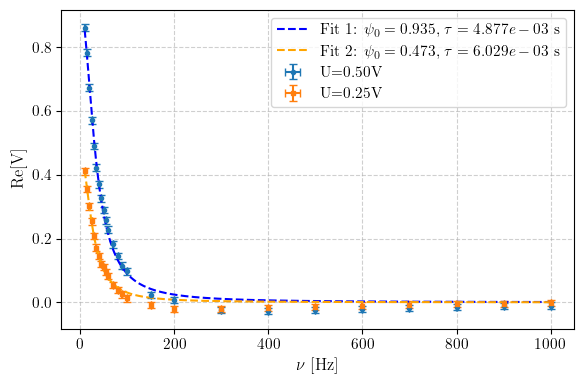

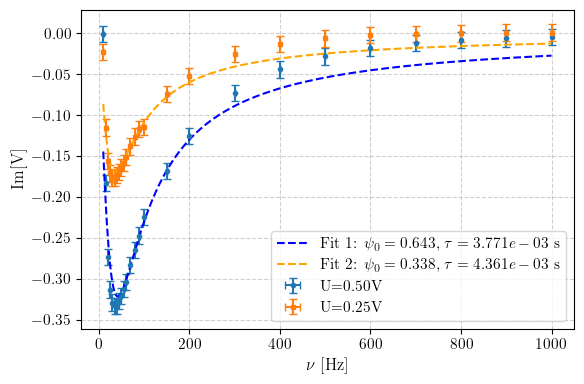

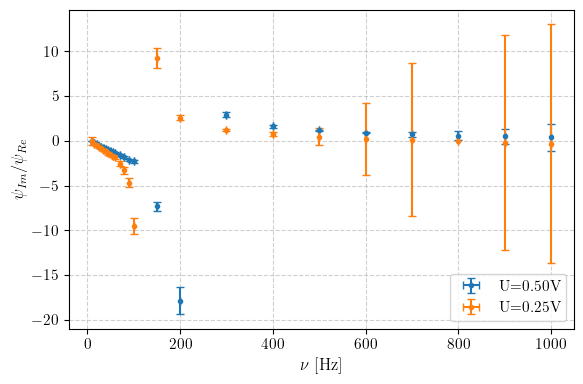

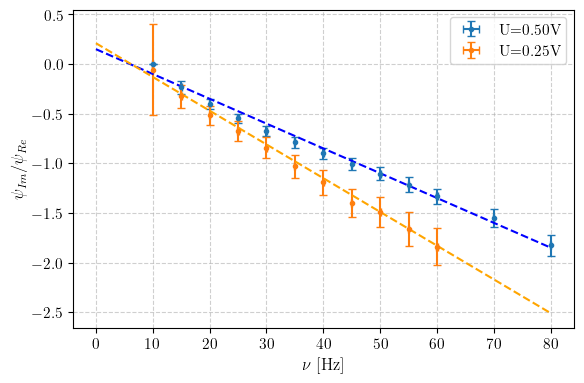

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------------------------
# LaTeX font setup
# ---------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# ---------------------------
# Data from table
# ---------------------------
nu = np.array([
    10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 80, 90, 100,
    150, 200, 300, 400, 500, 600, 700, 800, 900, 1000
])

Re1 = np.array([
    0.862, 0.784, 0.674, 0.571, 0.49, 0.423, 0.37, 0.326, 0.29, 0.257, 0.228,
    0.182, 0.145, 0.115, 0.097, 0.023, 0.007, -0.025, -0.027, -0.024,
    -0.02, -0.017, -0.014, -0.012, -0.01
])

Im1 = np.array([
    0.001, 0.183, 0.273, 0.313, 0.329, 0.333, 0.333, 0.327, 0.321, 0.312, 0.304,
    0.283, 0.265, 0.247, 0.224, 0.168, 0.125, 0.073, 0.044, 0.028,
    0.018, 0.012, 0.008, 0.006, 0.004
])

Re2 = np.array([
    0.411, 0.356, 0.301, 0.254, 0.209, 0.172, 0.145, 0.121, 0.11, 0.095, 0.082,
    0.054, 0.038, 0.025, 0.012, -0.008, -0.02, -0.021, -0.018, -0.014,
    -0.01, -0.007, -0.006, -0.005, -0.003
])

Im2 = np.array([
    0.023, 0.115, 0.156, 0.171, 0.176, 0.177, 0.173, 0.169, 0.164, 0.158, 0.151,
    0.138, 0.126, 0.117, 0.114, 0.074, 0.052, 0.025, 0.013, 0.006,
    0.002, 0.001, 0.0, -0.001, -0.001
])

# ---------------------------
# Errors
# ---------------------------
nu_err = 0.1
V_err = 0.01

# ---------------------------
# Model definitions
# ---------------------------
def psi_re_model(nu, psi0, tau):
    omega = 2 * np.pi * nu
    return psi0 / (1 + (omega * tau)**2)

def psi_im_model(nu, psi0, tau):
    omega = 2 * np.pi * nu
    return (psi0 * omega * tau) / (1 + (omega * tau)**2)

# ---------------------------
# Curve fits for both datasets
# ---------------------------
def fit_data(x, y, model, label):
    popt, pcov = curve_fit(model, x, y, p0=[1.0, 0.001])
    perr = np.sqrt(np.diag(pcov))
    print(f"{label}: ψ₀ = {popt[0]:.5f} ± {perr[0]:.5f}, τ = {popt[1]:.5e} ± {perr[1]:.1e} s")
    return popt, perr

popt_re1, perr_re1 = fit_data(nu, Re1, psi_re_model, "Re1")
popt_re2, perr_re2 = fit_data(nu, Re2, psi_re_model, "Re2")
popt_im1, perr_im1 = fit_data(nu, Im1, psi_im_model, "Im1")
popt_im2, perr_im2 = fit_data(nu, Im2, psi_im_model, "Im2")

# Smooth fit curves
nu_fit = np.linspace(min(nu), max(nu), 500)
Re1_fit = psi_re_model(nu_fit, *popt_re1)
Re2_fit = psi_re_model(nu_fit, *popt_re2)
Im1_fit = psi_im_model(nu_fit, *popt_im1)
Im2_fit = psi_im_model(nu_fit, *popt_im2)

# ---------------------------
# Plot Real part
# ---------------------------
plt.figure(figsize=(6, 4))
plt.errorbar(nu, Re1, xerr=nu_err, yerr=V_err, fmt='o', capsize=3, markersize=3, label=r'U=0.50V')
plt.errorbar(nu, Re2, xerr=nu_err, yerr=V_err, fmt='s', capsize=3, markersize=3, label=r'U=0.25V')

plt.plot(nu_fit, Re1_fit, '--', color="blue", label=rf'Fit 1: $\psi_0={popt_re1[0]:.3f}$, $\tau={popt_re1[1]:.3e}$ s')
plt.plot(nu_fit, Re2_fit, '--', color="orange", label=rf'Fit 2: $\psi_0={popt_re2[0]:.3f}$, $\tau={popt_re2[1]:.3e}$ s')

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'Re[V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Re_vs_nu_twofits.pdf", format='pdf', dpi=300)

# ---------------------------
# Plot Imaginary part
# ---------------------------
plt.figure(figsize=(6, 4))
plt.errorbar(nu, -Im1, xerr=nu_err, yerr=V_err, fmt='o', capsize=3, markersize=3, label=r'U=0.50V')
plt.errorbar(nu, -Im2, xerr=nu_err, yerr=V_err, fmt='s', capsize=3, markersize=3, label=r'U=0.25V')

plt.plot(nu_fit, -Im1_fit, '--', color="blue", label=rf'Fit 1: $\psi_0={popt_im1[0]:.3f}$, $\tau={popt_im1[1]:.3e}$ s')
plt.plot(nu_fit, -Im2_fit, '--', color="orange", label=rf'Fit 2: $\psi_0={popt_im2[0]:.3f}$, $\tau={popt_im2[1]:.3e}$ s')

plt.xlabel(r'$\nu$ [Hz]')
plt.ylabel(r'Im[V]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Im_vs_nu_twofits.pdf", format='pdf', dpi=300)


ye1=(V_err/Im1+V_err/Re1)
ye1[0]=0
ye2=(V_err/Im2+V_err/Re2)
#im/re
plt.figure(figsize=(6, 4))
plt.errorbar(nu, -Im1/Re1, yerr=np.abs(ye1), fmt="o", ms=3, capsize=3, xerr=nu_err, label="U=0.50V")
plt.errorbar(nu, -Im2/Re2, yerr=np.abs(ye2), fmt="o", ms=3, capsize=3, xerr=nu_err, label="U=0.25V")

plt.xlabel(r"$\nu$ [Hz]")
plt.ylabel(r"$\psi_{Im}/\psi_{Re}$")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Im_Re.pdf", format='pdf', dpi=300)


def fit_5(x, k, n):
    return k*x+n

y1=Im1[:-12]/Re1[:-12]
y2=Im2/Re2

popt1, perr1 = fit_data(nu[:-12], y1, fit_5, "1")

nu_fit1 = np.linspace(0, 80, 500)



plt.figure(figsize=(6, 4))
plt.errorbar(nu[:-12], -Im1[:-12]/Re1[:-12], yerr=np.abs(ye1[:-12]), fmt="o", ms=3, capsize=3, xerr=nu_err, label="U=0.50V")
plt.errorbar(nu[:-14], -Im2[:-14]/Re2[:-14], yerr=np.abs(ye2[:-14]), fmt="o", ms=3, capsize=3, xerr=nu_err, label="U=0.25V")
plt.plot(nu_fit1, -0.025*nu_fit1 + 0.15, "--", color="blue")
plt.plot(nu_fit1, -0.034*nu_fit1 + 0.21, "--", color="orange")

plt.xlabel(r"$\nu$ [Hz]")
plt.ylabel(r"$\psi_{Im}/\psi_{Re}$")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("Im_Re_fit.pdf", format='pdf', dpi=300)

plt.show()
